In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats

In [24]:
# Chargement et préparation des données
df = pd.read_excel("features_DF.xlsx")
print(df.shape)
df.head()

(2581, 78)


,Player,Nation,Pos,Team,Comp,Age,MP,Starts,Min,90s,...,Tkl+Int,Clr,Err,Tkl/90,Int/90,Blocks/90,Clr/90,Sh/90,KP/90,Ligue_Weight
0,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,34,37,37,3330,37.0,...,146,116,1,2.216216,1.729730,1.756757,3.135135,0.729730,0.351351,1.1
1,Abner,BRA,DF,Betis,La Liga,22,13,7,607,6.7,...,20,24,0,1.791045,1.194030,1.194030,3.582090,0.298507,0.298507,1.4
2,Francesco Acerbi,ITA,DF,Inter,Serie A,34,31,25,2425,26.9,...,74,85,2,1.226766,1.524164,0.929368,3.159851,0.669145,0.594796,1.2
3,Marcos Acuña,ARG,DF,Sevilla,La Liga,30,30,21,1912,21.2,...,80,36,0,2.688679,1.084906,0.754717,1.698113,0.235849,1.792453,1.4
4,Tosin Adarabioyo,ENG,DF,Fulham,Premier League,24,25,23,2085,23.2,...,56,140,1,1.293103,1.120690,0.862069,6.034483,0.646552,0.258621,1.5


In [25]:
#Séparer les variables descriptives (l'ACP n'utilise que les variables quantitatives)
meta_cols = [
    "Player", "Nation", "Pos", "Team", "Comp", "Year"
]

In [26]:
# Nettoyage : remplacer les virgules par des points
df= df.replace(",", ".", regex=True)
df = df.apply(pd.to_numeric, errors="ignore")

C:\Users\Dell\AppData\Local\Temp\ipykernel_15188\1306616843.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [27]:
features_def = [
    # Défense pure
    "Tkl+Int", "Blocks","Clr","Sh/90","Blocks/90",
    
    # Construction / offensives (pour latéraux)
    "KP", "PrgC", "PrgR", "CrsPA","G+A/90"
]



X = df[features_def]
X.describe()

,Tkl+Int,Blocks,Clr,Sh/90,Blocks/90,KP,PrgC,PrgR,CrsPA,G+A/90
count,2581.000000,2581.000000,2581.000000,2581.000000,2581.000000,2581.000000,2581.000000,2581.000000,2581.000000,2581.000000
mean,50.218907,21.730337,59.395196,0.526936,1.249789,10.376211,23.279349,39.953894,4.246804,0.102809
std,30.170172,13.516145,43.575564,0.356823,0.485293,11.490773,22.769179,50.357026,5.918758,0.116604
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.000000,11.000000,26.000000,0.254237,0.961538,3.000000,7.000000,4.000000,0.000000,0.000000
50%,46.000000,20.000000,49.000000,0.476190,1.212121,6.000000,16.000000,17.000000,2.000000,0.070000
75%,70.000000,30.000000,83.000000,0.738636,1.494845,14.000000,32.000000,62.000000,6.000000,0.150000
max,195.000000,99.000000,249.000000,2.727273,10.000000,110.000000,183.000000,348.000000,37.000000,0.940000


In [28]:
df_clean = df.loc[df[features_def].dropna().index]
X = df_clean[features_def]

print(f"\nNombre de joueurs après nettoyage: {len(df_clean)}")
print(f"\nValeurs manquantes:\n{X.isnull().sum()}")



Nombre de joueurs après nettoyage: 2581

Valeurs manquantes:
Tkl+Int      0
Blocks       0
Clr          0
Sh/90        0
Blocks/90    0
KP           0
PrgC         0
PrgR         0
CrsPA        0
G+A/90       0
dtype: int64


In [29]:
# Standardisation et ACP
X_scaled = StandardScaler().fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


In [30]:
# Variance expliquée
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"PC{i+1}: {var*100:.2f}%")
print(f"Cumul PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

PC1: 41.37%
PC2: 26.87%
PC3: 11.15%
PC4: 7.32%
PC5: 4.28%
Cumul PC1+PC2: 68.24%


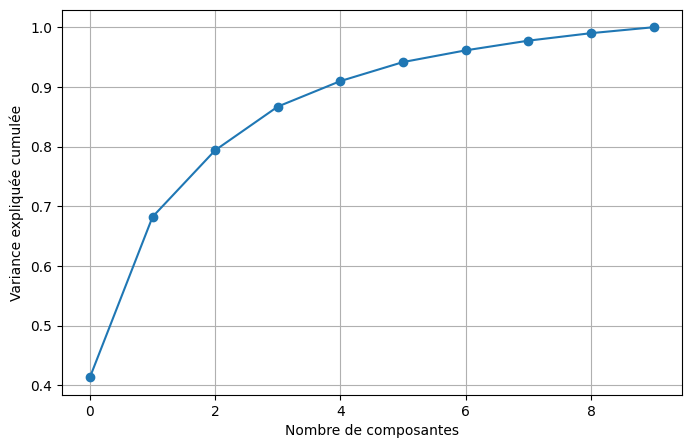

In [31]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.grid()
plt.show()


In [32]:
#Exploration des axes
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca2.components_.T,
    index=features_def,
    columns=["PC1", "PC2"]
)

print("\nCONTRIBUTIONS PC1")
print(loadings.sort_values("PC1", ascending=False))

print("\nCONTRIBUTIONS PC2")
print(loadings.sort_values("PC2", ascending=False))


CONTRIBUTIONS PC1
                PC1       PC2
PrgR       0.450727 -0.094557
KP         0.448417 -0.000083
PrgC       0.433583  0.011915
CrsPA      0.424275 -0.059250
Tkl+Int    0.256924  0.438571
G+A/90     0.235312 -0.162635
Blocks     0.175099  0.544713
Clr        0.018603  0.525321
Blocks/90 -0.096161  0.262119
Sh/90     -0.257157  0.356694

CONTRIBUTIONS PC2
                PC1       PC2
Blocks     0.175099  0.544713
Clr        0.018603  0.525321
Tkl+Int    0.256924  0.438571
Sh/90     -0.257157  0.356694
Blocks/90 -0.096161  0.262119
PrgC       0.433583  0.011915
KP         0.448417 -0.000083
CrsPA      0.424275 -0.059250
PrgR       0.450727 -0.094557
G+A/90     0.235312 -0.162635


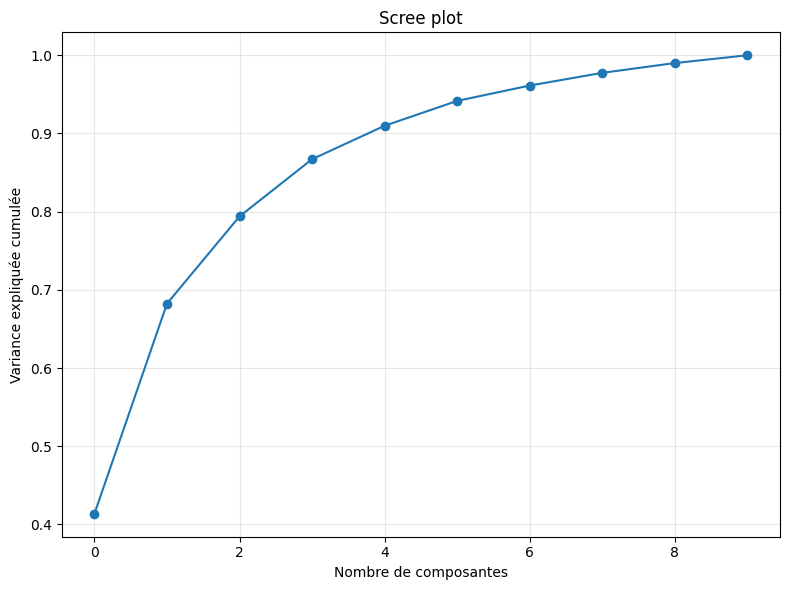

In [33]:
#Variance expliquée cumulée
plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Scree plot")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 2000x1500 with 0 Axes>

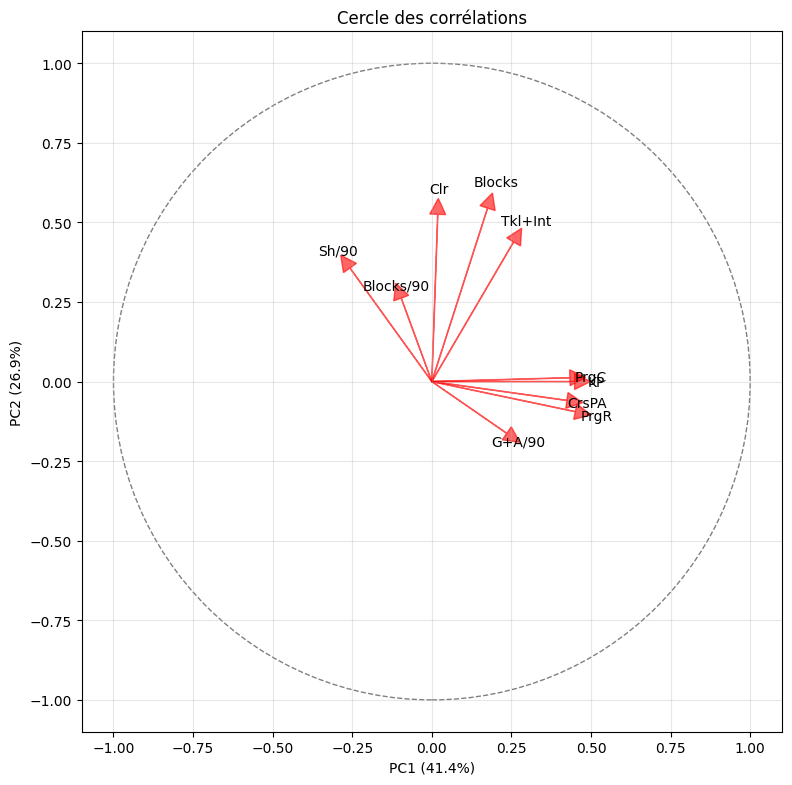

In [34]:
#Cercle des correlations
plt.figure(figsize=(20,15))
circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
fig, ax2 = plt.subplots(figsize=(8,8))
ax2.add_artist(circle)

for i, var in enumerate(features_def):
    ax2.arrow(0, 0, 
             loadings.iloc[i, 0], 
             loadings.iloc[i, 1],
             head_width=0.05, 
             head_length=0.05, 
             fc='red', 
             ec='red',
             alpha=0.6)
    ax2.text(loadings.iloc[i, 0]*1.15, 
            loadings.iloc[i, 1]*1.15, 
            var, 
            ha='center', 
            va='center',
            fontsize=10)

ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title('Cercle des corrélations')
ax2.grid(alpha=0.3)
ax2.set_aspect('equal')
plt.tight_layout()
plt.show()

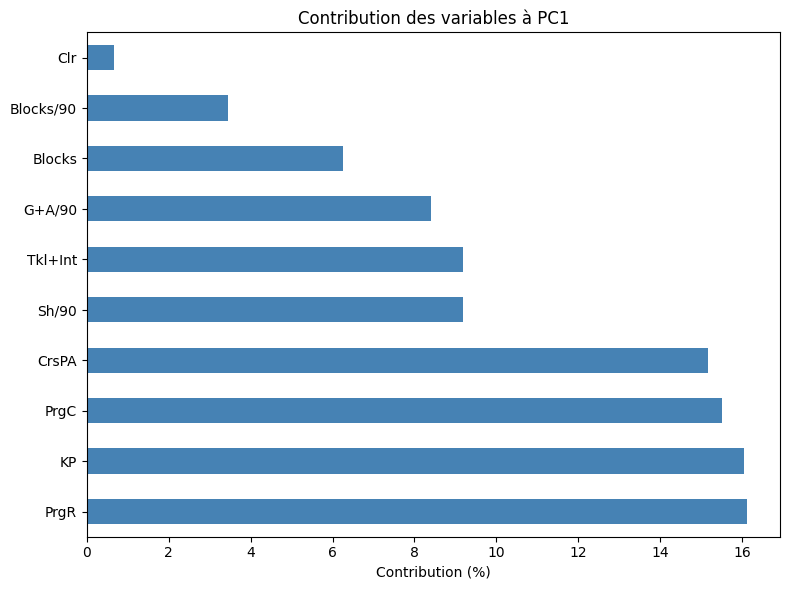

In [35]:
plt.figure(figsize=(8,6))
contrib = loadings.abs() * 100 / loadings.abs().sum()
contrib['PC1'].sort_values(ascending=False).plot(kind='barh', color='steelblue')
plt.title('Contribution des variables à PC1')
plt.xlabel('Contribution (%)')
plt.tight_layout()
plt.show()

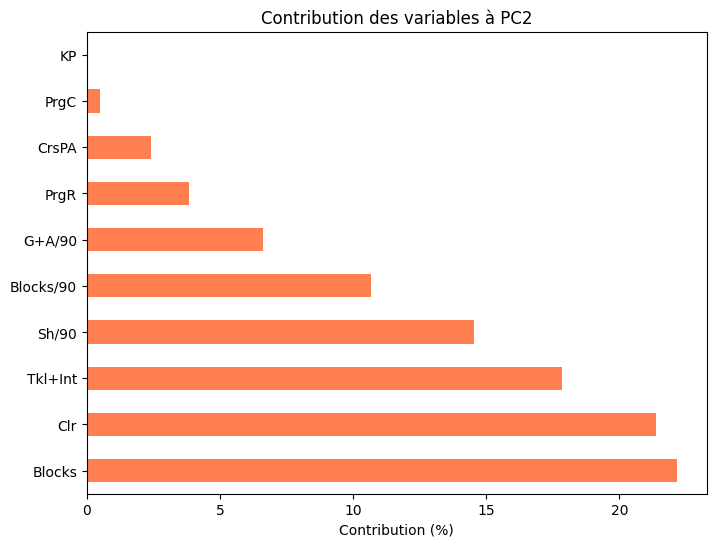

In [36]:
# 4.4 Contributions à PC2
plt.figure(figsize=(8,6))
contrib['PC2'].sort_values(ascending=False).plot(kind='barh', color='coral')
plt.title('Contribution des variables à PC2')
plt.xlabel('Contribution (%)')
plt.show()


In [37]:
df_pca = pd.DataFrame(X_pca2, columns=["PC1", "PC2"], index=df_clean.index)
df_results = df_clean.copy()
df_results["PC1"] = df_pca["PC1"]
df_results["PC2"] = df_pca["PC2"]

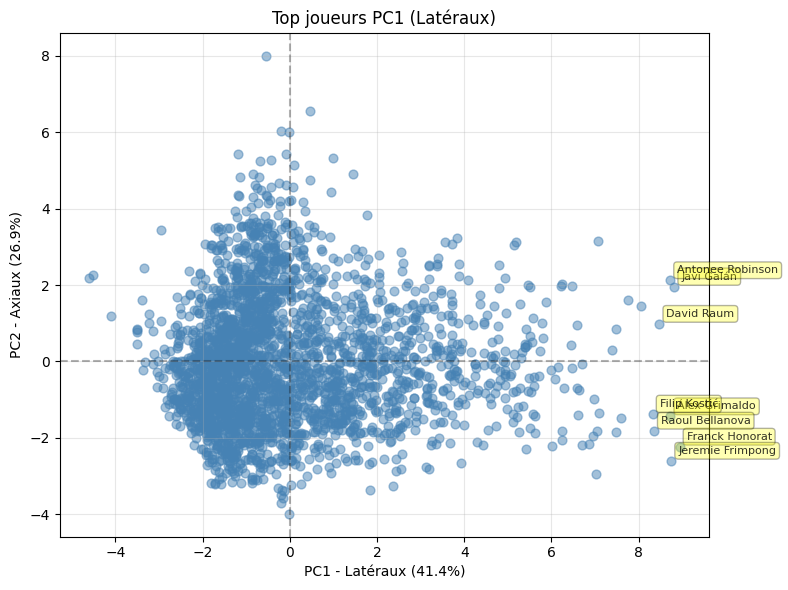

In [38]:
#Biplot top joueurs PC1
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"], 
                     alpha=0.5, s=40, c='steelblue')

top_players = df_results.nlargest(8, 'PC1')
for idx, row in top_players.iterrows():
    plt.annotate(row['Player'], 
                 (row['PC1'], row['PC2']),
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=8,
                 alpha=0.8,
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))

plt.xlabel(f'PC1 - Latéraux ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 - Axiaux ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Top joueurs PC1 (Latéraux)')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

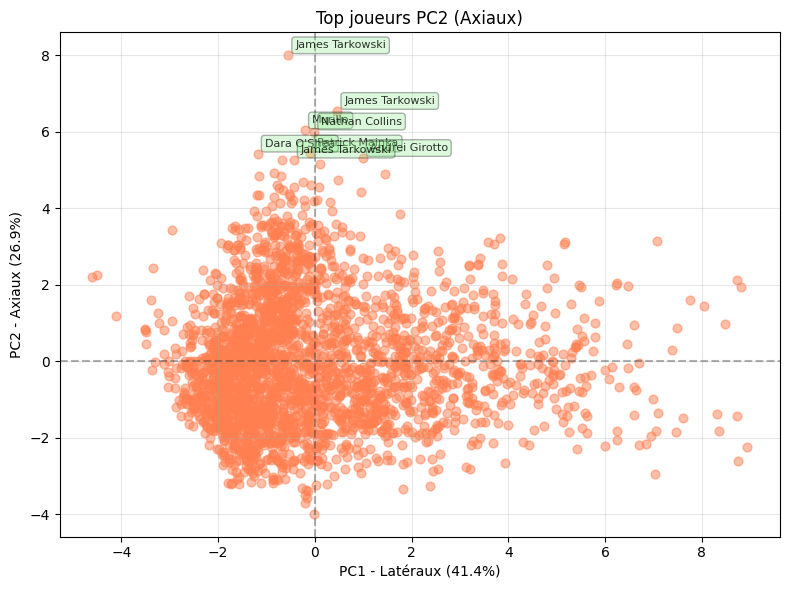

In [39]:
#Biplot top joueurs PC2
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"], 
                      alpha=0.5, s=40, c='coral')

top_scorers = df_results.nlargest(8, 'PC2')
for idx, row in top_scorers.iterrows():
    plt.annotate(row['Player'], 
                 (row['PC1'], row['PC2']),
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=8,
                 alpha=0.8,
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', alpha=0.3))

plt.xlabel(f'PC1 - Latéraux ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 - Axiaux ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Top joueurs PC2 (Axiaux)')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

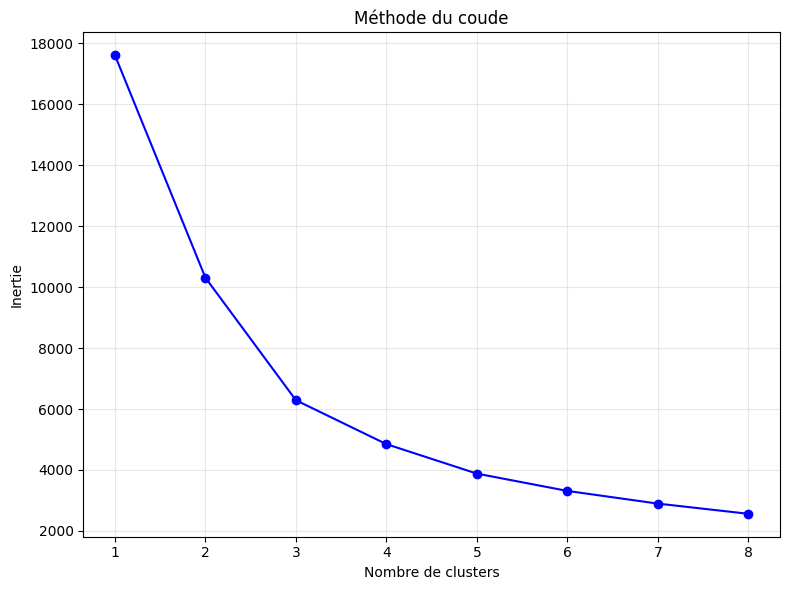

In [40]:
inertias = []
K_range = range(1, 9)


for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca2)
    inertias.append(kmeans.inertia_)


plt.figure(figsize=(8,6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

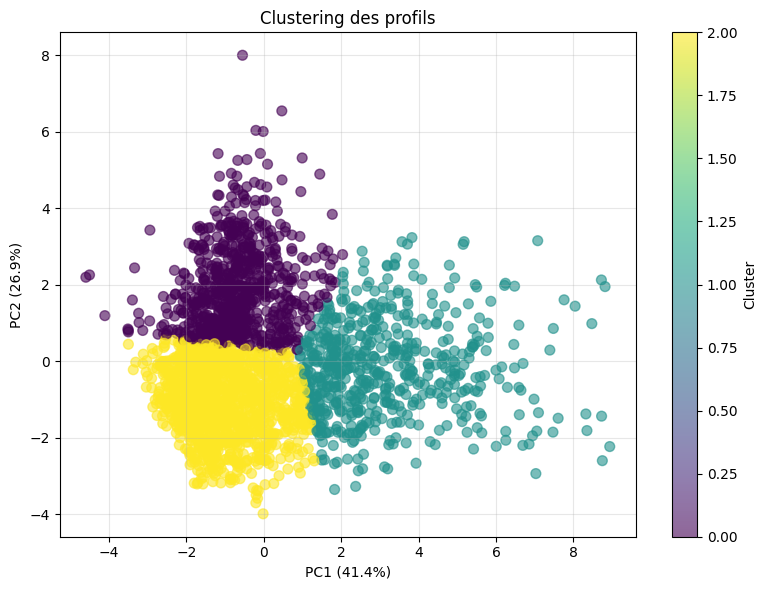

In [41]:
#Clustering K-means
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_results['Cluster'] = kmeans.fit_predict(X_pca2)

plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"], 
                      c=df_results['Cluster'], 
                      cmap='viridis', 
                      alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Clustering des profils')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

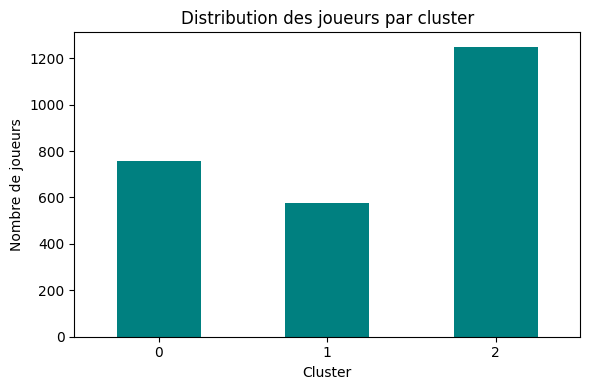

In [42]:
# Distribution des joueurs par cluster
plt.figure(figsize=(6,4))
df_results['Cluster'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Distribution des joueurs par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre de joueurs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
print("\n🎯 Latéraux (PC1 élevé, PC2 faible):")
creators = df_results[(df_results['PC1'] > df_results['PC1'].quantile(0.85)) & 
                      (df_results['PC2'] < df_results['PC2'].median())]
print(creators.nlargest(10,'PC1')[['Player', 'Team', 'Comp', 'PC1', 'PC2']].to_string())

print("\n⚽ Centraux purs (PC2 élevé, PC1 faible):")
scorers = df_results[(df_results['PC2'] > df_results['PC2'].quantile(0.85)) & 
                     (df_results['PC1'] < df_results['PC1'].median())]
print(scorers.nlargest(10,'PC2')[['Player', 'Team', 'Comp', 'PC1', 'PC2']].to_string())

print("\n⭐ Défenseurs complets (PC1 et PC2 élevés):")
complete = df_results[(df_results['PC1'] > df_results['PC1'].quantile(0.90)) & 
                      (df_results['PC2'] > df_results['PC2'].quantile(0.90))]
print(complete[['Player', 'Team', 'Comp', 'PC1', 'PC2']].to_string())


🎯 Latéraux (PC1 élevé, PC2 faible):
                Player        Team        Comp       PC1       PC2
1217    Franck Honorat    Gladbach  Bundesliga  8.938256 -2.228394
1136  Jeremie Frimpong  Leverkusen  Bundesliga  8.747077 -2.597583
1170     Álex Grimaldo  Leverkusen  Bundesliga  8.727642 -1.434098
945    Raoul Bellanova      Torino     Serie A  8.348977 -1.810579
441       Filip Kostić    Juventus     Serie A  8.321485 -1.376579
293   Jeremie Frimpong  Leverkusen  Bundesliga  7.605253 -1.488438
2038     Álex Grimaldo  Leverkusen  Bundesliga  7.470934 -1.852060
807    Emanuele Valeri   Cremonese     Serie A  7.096703 -1.342959
741         Borna Sosa   Stuttgart  Bundesliga  7.053703 -1.824015
2061     Luis Henrique   Marseille     Ligue 1  7.029207 -2.934779

⚽ Centraux purs (PC2 élevé, PC1 faible):
                 Player          Team            Comp       PC1       PC2
2310        Dara O'Shea  Ipswich Town  Premier League -1.181455  5.427710
1008      Julian Chabot          Köl

In [44]:
cluster_names = {
    0: "Type 0",
    1: "Type 1", 
    2: "Type 2"
}

for cluster in range(optimal_k):
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster} - {cluster_names[cluster]}")
    print(f"{'='*70}")
    
    cluster_data = df_results[df_results['Cluster'] == cluster]
    print(f"Nombre de joueurs: {len(cluster_data)}")
    
    print(f"\nTop 5 joueurs:")
    print(cluster_data.nlargest(5, 'PC1')[['Player', 'Team', 'PC1', 'PC2']].to_string())
    
    print(f"\nMoyennes des features:")
    means = cluster_data[features_def].mean()
    for feat, val in means.items():
        print(f"  {feat:15s}: {val:6.2f}")
    
    print(f"\nCaractéristiques PC:")
    print(f"  PC1 moyen: {cluster_data['PC1'].mean():6.2f} (latéraux)")
    print(f"  PC2 moyen: {cluster_data['PC2'].mean():6.2f} (axiaux)")


CLUSTER 0 - Type 0
Nombre de joueurs: 756

Top 5 joueurs:
                 Player            Team       PC1       PC2
2108       James Justin  Leicester City  2.035406  2.789115
557     Tyrick Mitchell  Crystal Palace  1.844786  2.062406
575   Vitaliy Mykolenko         Everton  1.789152  2.674507
2070     Omar El Hilali        Espanyol  1.769093  3.841372
308           Óscar Gil        Espanyol  1.751586  2.100002

Moyennes des features:
  Tkl+Int        :  70.24
  Blocks         :  34.25
  Clr            : 106.59
  Sh/90          :   0.82
  Blocks/90      :   1.45
  KP             :   6.71
  PrgC           :  16.83
  PrgR           :  12.55
  CrsPA          :   1.43
  G+A/90         :   0.07

Caractéristiques PC:
  PC1 moyen:  -0.68 (latéraux)
  PC2 moyen:   1.89 (axiaux)

CLUSTER 1 - Type 1
Nombre de joueurs: 576

Top 5 joueurs:
                Player        Team       PC1       PC2
1217    Franck Honorat    Gladbach  8.938256 -2.228394
295         Javi Galán  Celta Vigo  8.817552  